In [1]:
import numpy as np
import pandas as pd #
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.preprocessing
import sklearn.linear_model
import matplotlib.pyplot as plt
import imblearn # Bilioteca para aprendizaje desde datos desbalanceados

In [2]:
df=pd.read_csv("vgsales.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'vgsales.csv'

Análisis Exploratorio de Datos

In [3]:
df.head()

NameError: name 'df' is not defined

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [ ]:
df['Platform']=df['Platform'].astype('category')
df['Platform']=df['Platform'].cat.codes

df['Genre']=df['Genre'].astype('category')
df['Genre']=df['Genre'].cat.codes

df['Publisher']=df['Publisher'].astype('category')
df['Publisher']=df['Publisher'].cat.codes

df['Name']=df['Name'].astype('category')
df['Name']=df['Name'].cat.codes
df

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,11007,26,2006.0,10,359,41.49,29.02,3.77,8.46,82.74
1,2,9327,11,1985.0,4,359,29.08,3.58,6.81,0.77,40.24
2,3,5573,26,2008.0,6,359,15.85,12.88,3.79,3.31,35.82
3,4,11009,26,2009.0,10,359,15.75,11.01,3.28,2.96,33.00
4,5,7346,5,1996.0,7,359,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,11101,6,2002.0,4,269,0.01,0.00,0.00,0.00,0.01
16594,16597,5796,7,2003.0,8,241,0.01,0.00,0.00,0.00,0.01
16595,16598,8144,16,2008.0,6,21,0.00,0.00,0.00,0.00,0.01
16596,16599,5014,4,2010.0,5,8,0.00,0.01,0.00,0.00,0.01


In [ ]:
df=df.drop(['Rank', 'Year'], axis=1)

In [ ]:
df.describe()

,Name,Platform,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,5792.402880,15.797988,4.928124,292.579287,0.264667,0.146652,0.077782,0.048063,0.537441
std,3323.522815,8.392298,3.762015,178.145564,0.816683,0.505351,0.309291,0.188588,1.555028
min,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,2921.250000,7.000000,1.000000,137.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,5839.500000,16.000000,5.000000,323.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,8699.750000,21.000000,8.000000,456.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,11492.000000,30.000000,11.000000,577.000000,41.490000,29.020000,10.220000,10.570000,82.740000


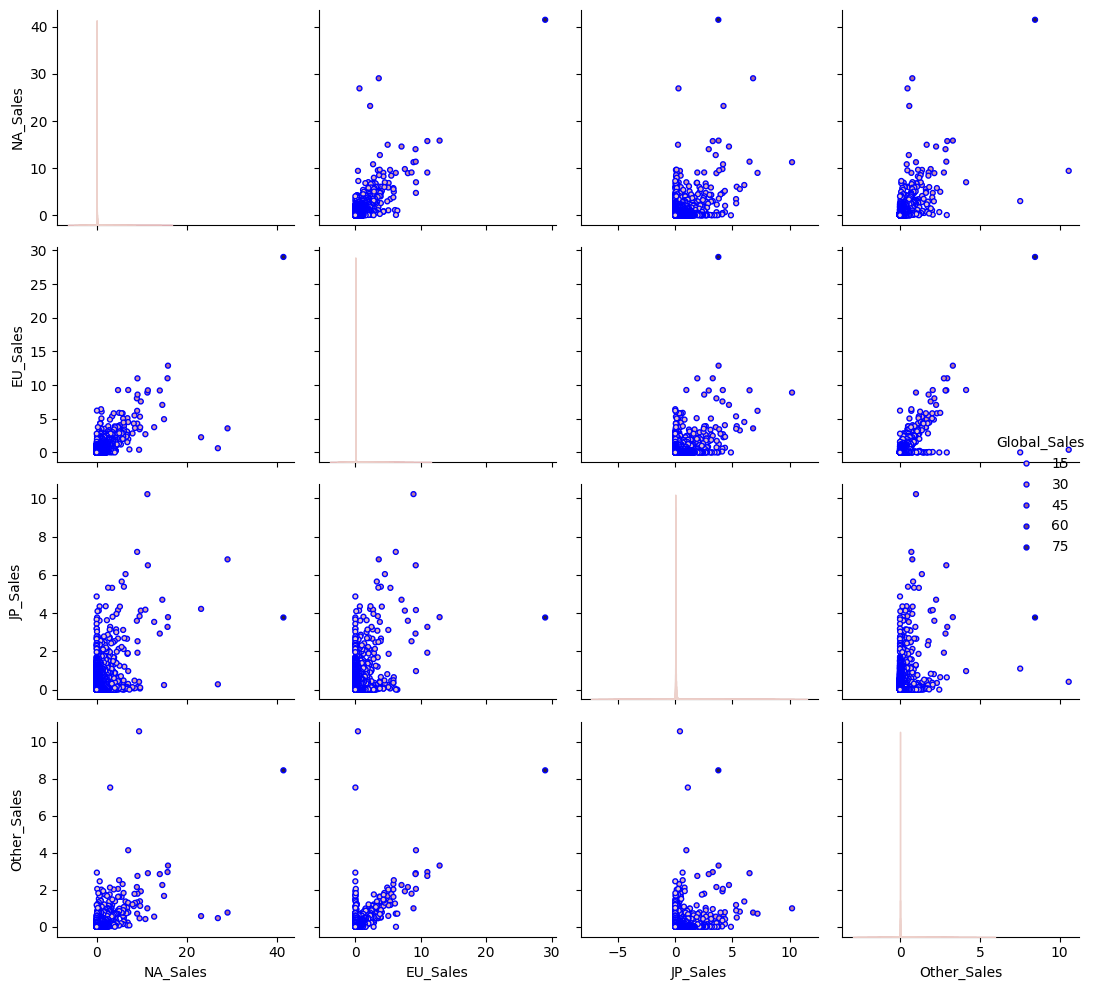

In [ ]:
sns.pairplot(data=df,
             diag_kind="kde",
             markers=".",
             plot_kws=dict(s=50, edgecolor="b", linewidth=1),
             hue="Global_Sales",
             vars=["NA_Sales",
                   "EU_Sales",
                   "JP_Sales","Other_Sales"
                   ],
                   diag_kws=dict(fill=True))

plt.tight_layout()
plt.show()

In [ ]:
df.isnull().sum()

,0
Name,0
Platform,0
Genre,0
Publisher,0
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0
Global_Sales,0


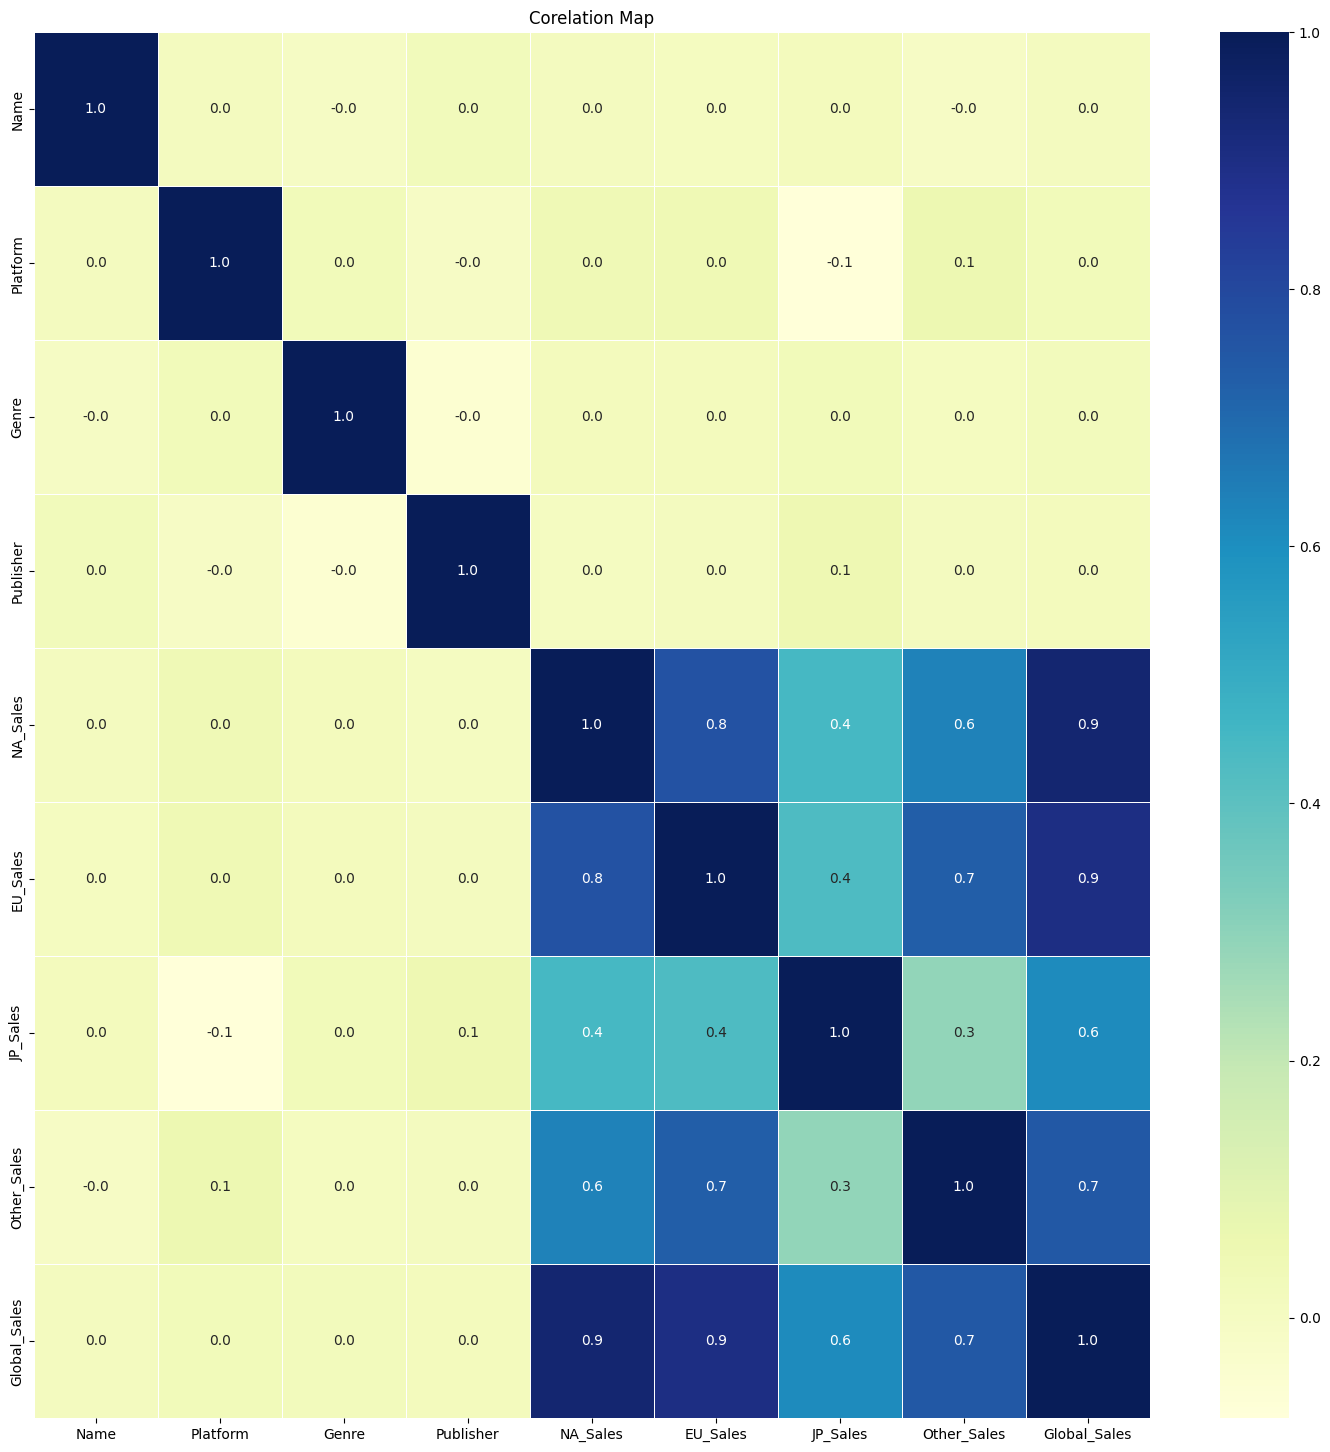

In [ ]:
f,ax = plt.subplots(figsize=(18, 18))
sns.heatmap(df.corr(), annot=True, linewidths=.5, cmap="YlGnBu",fmt= '.1f',ax=ax)
plt.title('Corelation Map')
plt.show()

In [ ]:
y=df.Global_Sales.values
x=df.drop(['Global_Sales'],axis=1)

In [ ]:
# train/test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)

Lineal Regression

R² es una medida estadística de qué tan cerca están los datos de la línea de regresión ajustada. También se le conoce como coeficiente de determinación o coeficiente de determinación múltiple para regresión múltiple. Para decirlo en un lenguaje más sencillo, R-cuadrado es una medida de ajuste para modelos de regresión lineal.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)
print('R2 score:',r2_score(y_test,y_pred))
y_pred = lr.predict(x_test)
y_pred_lr = y_pred
y_true = y_test
train_score = lr.score(x_train, y_train)
print(f'score de entrenamiento: {train_score*100}')
test_score =lr.score(x_test, y_test)
print(f'score para pruebas: {test_score*100}')
print("Root Mean Squared Error:",np.sqrt(mean_squared_error(y_test, y_pred)))
print('MSE', mean_squared_error(y_test, y_pred))
print('MAE', mean_absolute_error(y_test, y_pred))

R2 score: 0.9999863929913662
score de entrenamiento: 99.99894742162049
score para pruebas: 99.99863929913661
Root Mean Squared Error: 0.005148910877557681
MSE 2.6511283225031804e-05
MAE 0.002863454438227108


El error cuadrático medio (MSE) es la función de pérdida de regresión más utilizada. MSE es la pérdida promedio de fotogramas por muestra en todo el conjunto de datos. Para calcular el MSE, sume todas las pérdidas de cuadros para muestras individuales y luego divida por el número de muestras.

El error absoluto es la diferencia entre los valores estimados y los valores reales. Para ser exactos, es la media del valor absoluto de cada diferencia entre el valor real y el valor previsto para esa muestra en toda la muestra del conjunto de datos.

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

modelo = XGBRegressor(n_estimators=100, learning_rate=0.1)

modelo.fit(x_train, y_train)
y_pred = modelo.predict(x_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.26820183674734077
R2: 0.963080534370631


Regresión Logistica predicción de Variable categórica

In [ ]:
def bar_plot(variable):
    # get feature
    var = df[variable]
    # count number of categorical variable(value/sample)
    varValue = var.value_counts()

    # visualize
    plt.figure(figsize = (9,3))
    plt.bar(varValue.index, varValue)
    plt.xticks(varValue.index, varValue.index.values)
    plt.ylabel("Frequency")
    plt.title(variable)
    plt.show()
    print("{}:\n{}".format(variable,varValue))

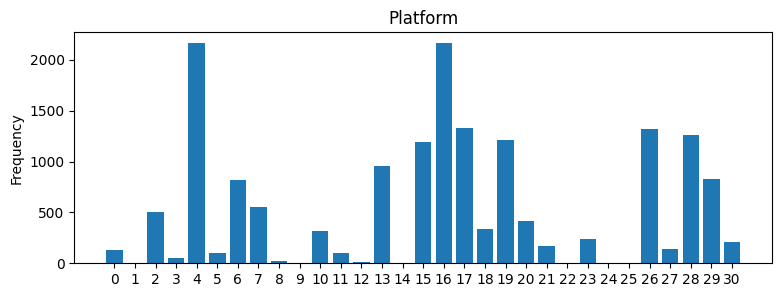

Platform:
Platform
4     2163
16    2161
17    1329
26    1325
28    1265
19    1213
15    1196
13     960
29     824
6      822
7      556
2      509
20     413
18     336
10     319
23     239
30     213
21     173
27     143
0      133
11      98
5       98
3       52
8       27
12      12
22       6
25       6
1        3
24       2
9        1
14       1
Name: count, dtype: int64


In [ ]:
bar_plot('Platform')

In [ ]:
y=df.Platform.values
x=df.drop(['Platform'],axis=1)

In [ ]:
# train/test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)

In [ ]:
from sklearn.linear_model import LogisticRegression
#ayuda a mejorar Recall y F1-score cuando hay clases minoritarias.
model = LogisticRegression(class_weight='balanced',max_iter=1000)
model.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
# Predicciones
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:,1]

In [ ]:
#Calcular métricas
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.03      0.47      0.06        45
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00       163
           3       0.00      0.00      0.00        14
           4       0.00      0.00      0.00       686
           5       0.03      0.18      0.05        33
           6       0.00      0.00      0.00       253
           7       0.00      0.00      0.00       168
           8       0.00      0.00      0.00         7
           9       0.00      0.00      0.00         0
          10       0.12      0.01      0.02        96
          11       0.06      0.24      0.10        21
          12       0.00      0.67      0.00         3
          13       0.11      0.19      0.14       270
          14       0.00      0.00      0.00         1
          15       0.00      0.00      0.00       361
          16       0.00      0.00      0.00       651
          17       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

F1-Score: combina precision y recall en una sola métrica, siendo ideal cuando el dataset está desbalanceado o cuando ambos tipos de error son importantes.

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

y=df.Genre.values
x=df.drop(['Genre'],axis=1)
# train/test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)

# Modelo XGBoost
modelo = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,class_weight='balanced'
)

# Entrenamiento
modelo.fit(x_train, y_train)

# 7. Predicción
y_pred = modelo.predict(x_test)
y_prob = modelo.predict_proba(x_test)

# 8. Evaluación
print(classification_report(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:22:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.33      0.69      0.45      1019
           1       0.37      0.34      0.36       390
           2       0.69      0.26      0.38       240
           3       0.39      0.24      0.30       518
           4       0.38      0.23      0.29       244
           5       0.33      0.19      0.24       168
           6       0.49      0.20      0.28       403
           7       0.36      0.38      0.37       420
           8       0.56      0.14      0.22       411
           9       0.42      0.19      0.26       262
          10       0.51      0.61      0.55       708
          11       0.34      0.26      0.29       197

    accuracy                           0.39      4980
   macro avg       0.43      0.31      0.33      4980
weighted avg       0.42      0.39      0.37      4980

